In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [3]:
from sequence_parser import Sequence, Variable, Variables
from sequence_parser.iq_port import Port
from sequence_parser.instruction import *

In [4]:
import sklearn
from sklearn.decomposition import PCA

In [5]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

## active reste
ef freq

In [6]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [7]:
header = "D:/K_sunada/result/CDY154/"
ef_freq = "/2024-01-17/2024-01-17T174147_3fdf93c9-72_active_reset_ef_freq"
dd = datadict_from_hdf5(header + ef_freq +"/data")

S11 = dd['s11']['values']
freq = dd['ef_freq']['values']
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

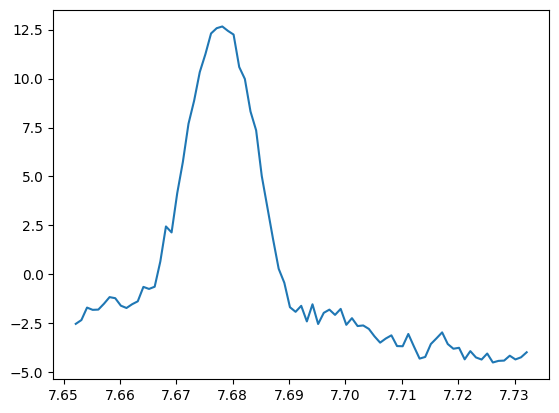

In [8]:
plt.plot(freq, S11_PCA)

In [9]:
par_ini = {
    'amp': 8,
    'const':0,
    'center':7.682,
    'k':0.008
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [10]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = -S11_PCA, params = params, freq = freq)
result

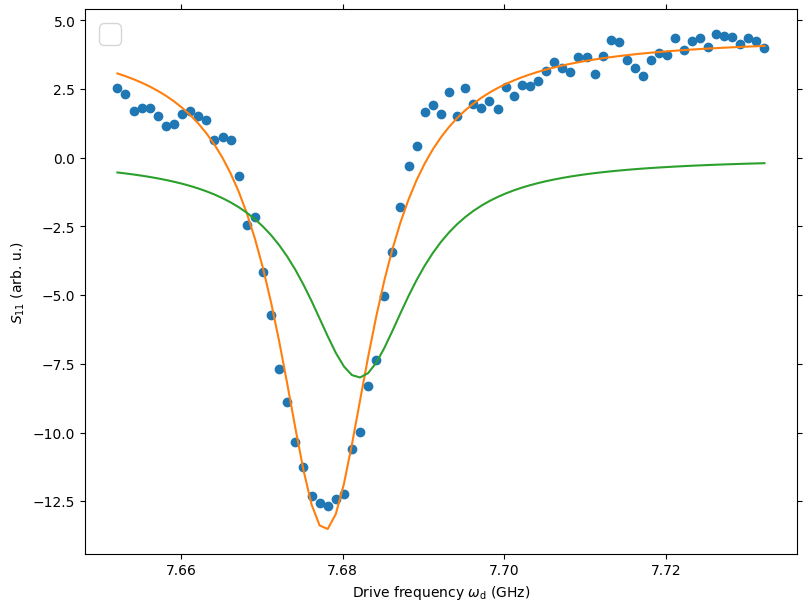

In [11]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

ef amplitude

In [12]:
header = "D:/K_sunada/result/CDY154/"
ef_amp =  "/2024-01-17/2024-01-17T174938_589d1d89-73_active_reset_ef_amp"
dd = datadict_from_hdf5(header + ef_amp +"/data")

S11 = dd['s11']['values'][0:60]
freq = dd['ef_amplitude']['values'][0:60]
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

In [13]:
def cos(x, amp, freq, phi, const):
    return amp * np.cos(2*np.pi*x*freq+phi) + const

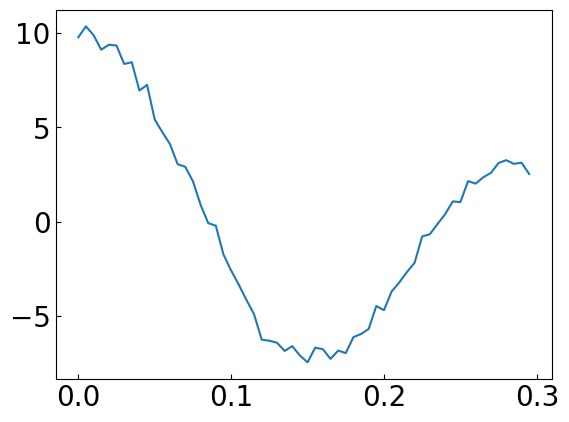

In [14]:
plt.plot(freq, S11_PCA)

In [15]:
par_ini= {'amp': 2,'freq':1/0.4,'phi':np.pi,'const':0}
par_min= {'amp': 0,'freq':0,'phi':-2*np.pi,'const':-np.inf}
par_max= {'amp': np.inf,'freq':np.inf,'phi':2*np.pi,'const':np.inf}
par_vary= {'amp': True,'freq': True,'phi': True,'const': True}

In [16]:
model = lmfit.Model(cos)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = -S11_PCA, params = params, x = freq)
result

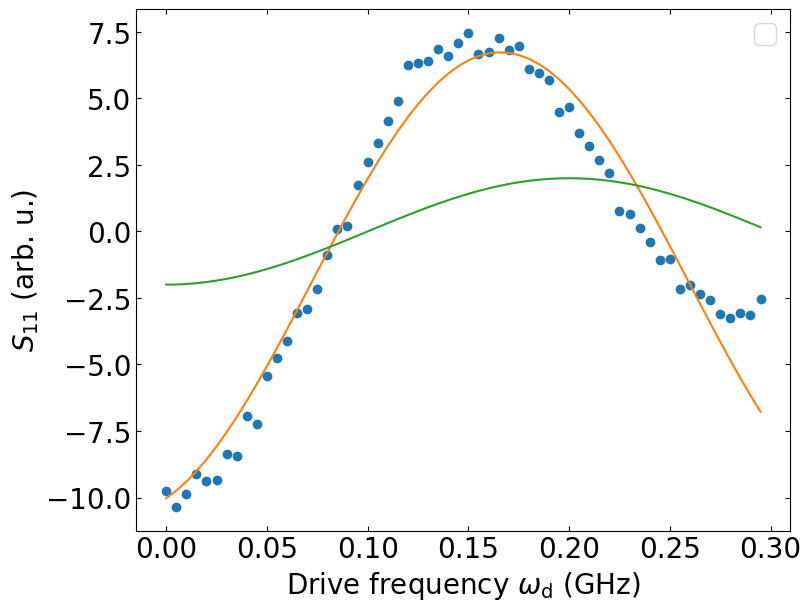

In [17]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

In [18]:
1/2/2.66734711

0.18745216853310104

## FFT

In [19]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [20]:
def FFT_show(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = (dd['time']['values'])[i]
    y = (dd['waveform']['values'])[i] #- dd['waveform1']['values'] 
    readout_freq = 10.306e9
    readout_if_freq = (10.423-10.306)*1e9
    readout_lo_freq = readout_freq + readout_if_freq

    x_fft = FFT(x, y)[0]
    y_fft = FFT(x, y)[1]

    fig, (ax1, ax2) = plt.subplots(nrows=2)
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y)
    # ax1.plot(x, np.abs(signal.hilbert(y)))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")

    ax2.set_xlabel('Frequency(Hz)')
    ax2.set_ylabel('Power (arb. u.)')
    ax2.plot(readout_lo_freq-x_fft, y_fft)
    
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    # ax2.set_xlim(0, 250e6)
    ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
    peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]

    plt.show()
    return peak, y


In [21]:
def waveform_show(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][i]
    y = dd['waveform']['values'][i]# - dd['waveform1']['values']
    label = dd['fogi_frequency']['values'][i]

    plt.rcParams["font.size"] = 14
    fig, (ax1) = plt.subplots(nrows=1)
    ax1.set_xlabel('Time (ns)', size = "large")
    ax1.set_ylabel('Waveform (V)', size = "large")
    ax1.plot(x,  y)
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()
    return label


In [22]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 1/17 photon shape & photon number

In [23]:
header = "D:/K_sunada/result/CDY154/"

In [24]:
def square(freq, amp, duration):
    x = np.linspace(0, duration-1, duration)
    y = amp* np.cos(2*np.pi* freq*(x*1e-9))
    env = np.zeros(duration) + amp
    return x, y, env

In [25]:
from scipy.constants import *

In [26]:
def watt_dbm(watt):
    return 10*np.log10(watt*1e3)

def dbm_watt(dBm):
    return (10**(dBm/10))*1e-3

In [27]:
dbm_watt(-18.05)

1.5667510701081486e-05

In [28]:
def photon_number(pulse, freq, atten_fixed, atten_fridge, atten_RT, sample_rate, P_vna):
    #pulse: [x, y, env], atten: dBm, samplerate: s, P_vna: W (AWG amp=1.0)
    x = pulse[0]
    y = pulse[2] #env

    atten_W = 10**((atten_fixed + atten_fridge + atten_RT)/10)
    ene = 0
    for t in range(int(len(x)/sample_rate*1e-9)):
        ene = ene + (y[2*t]**2)*sample_rate
    print(watt_dbm(P_vna*atten_W))

    return ene * P_vna * atten_W/ (2*np.pi*hbar*freq)


In [29]:
ene = 0
x = [0, 1, 2, 3, 4, 5, 6]
y = [1, 1, 1, 1, 1, 1, 1]
for t in range(int(len(x)/2)):
    ene = ene + (y[2*t]**2)*2

ene

6

Generated photon shape

array([-85000000.,  85000000.])

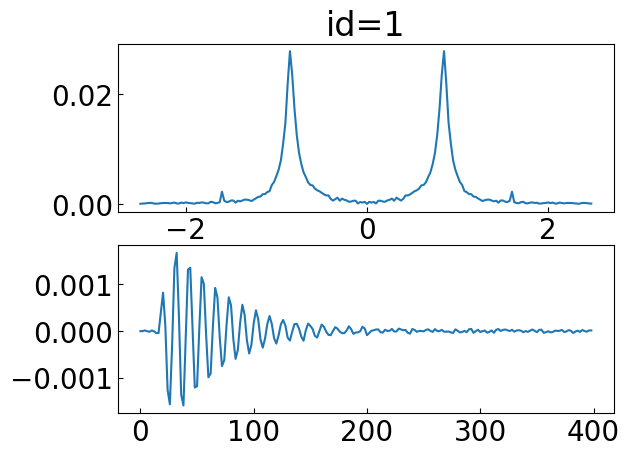

In [30]:
id = 7
duration = 200
data = "/2024-01-17/2024-01-17T143735_84bc5e10-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

# x_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[0]
# y_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[1]
peak1 = x_fft[signal.argrelmax(y_fft, order=50)]
fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_title("id=1")
ax1.plot(x_fft, y_fft)
ax2.plot(x, y)
peak1

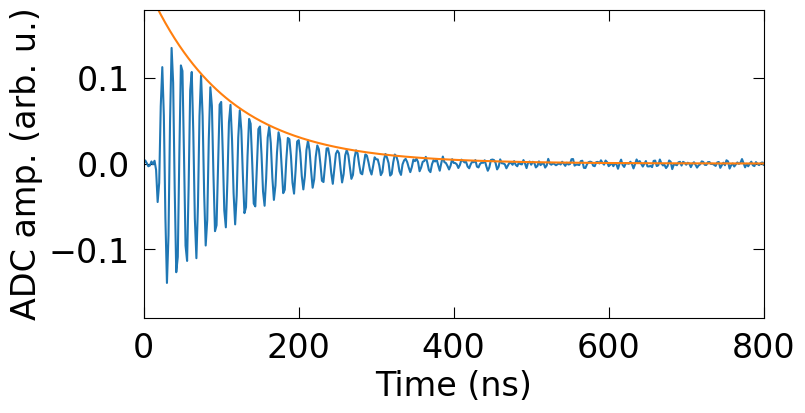

In [44]:
id = 4
duration = 520
ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
data = "/2024-01-17/2024-01-17T143735_84bc5e10-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
y_shift =  y[13:duration-7]* np.exp(-1j*2 *np.pi* ph_if[id]*(x[13:duration-7]*1e-9))
y_LPF = np.array(np.abs(LPF(y_shift, 500e6, 15e6, 40e6, 5, 40))*2)

amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340	, 0.02609383]
fig, ax = plt.subplots(figsize=(8, 4),nrows=1)
plt.rcParams["font.size"] = 24
# plt.title("Rabi(amp)")
plt.tick_params(pad = 10,top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.major.size"] = 8
plt.rcParams["ytick.major.size"] = 8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

ax.plot(x, y*1e2)
ax.plot(x, amp[id]*np.exp(-gamma[id]*x)*1e2)
plt.title("")
ax.set_ylim(-0.18, 0.18)
ax.set_xlim(0, 800)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('ADC amp. (arb. u.)')
# plt.savefig('photon08.png', bbox_inches='tight')
plt.show()

In [32]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

par_ini_t1 = {'gamma': 1/400,'amp':0.4,'const':0}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':False}
model = lmfit.Model(Dephase)

In [33]:
params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
# result1 = model.fit(data = LPF_env_1[::-1][50:], params = params, delay = x_1[50:])
result = model.fit(data = y_LPF[0:250], params = params, delay = x[13:duration-7][0:250])

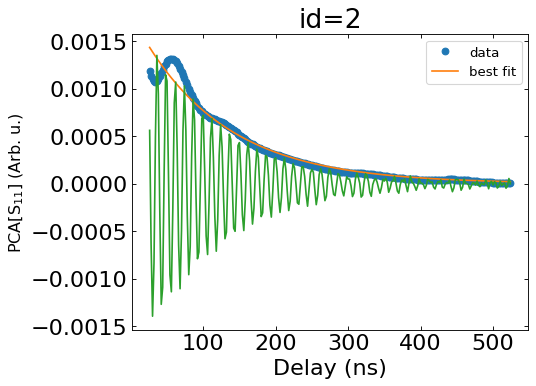

In [34]:
fig, (ax) = plt.subplots(dpi=80)
plt.title("id=2")
plt.rcParams["font.size"] = 12
plt.tick_params(top='on',bottom='on',left='on',right='on',)
result.plot_fit(ax = ax)
plt.plot(x[13:duration-7][0:250], dd['waveform']['values'][id][13:duration-7][0:250])

# plt.plot(x_2,result2.init_fit, label='init fit')

# ax.set_ylim(-8, 15)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Delay (ns)')#, size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. u.)', size='large')

plt.show()
result

In [35]:
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340	, 0.02609383]

## Photon shape

In [36]:
0.00972759/2

0.004863795

[ 60  62  64  66  68  70  72  74  76  78  80  82  84  86  88  90  92  94
  96  98 100 102 104 106 108 110 112 114 116 118 120 122 124 126 128 130
 132 134 136 138 140 142 144 146 148 150 152 154 156 158 160 162 164 166
 168 170 172 174 176 178 180 182 184 186 188 190 192 194 196 198 200 202
 204 206 208 210 212 214 216 218 220 222 224 226 228 230 232 234 236 238
 240 242 244 246 248 250 252 254 256 258 260 262 264 266 268 270 272 274
 276 278 280 282 284 286 288 290 292 294 296 298 300 302 304 306 308 310
 312 314 316 318 320 322 324 326 328 330 332 334 336 338 340 342 344 346
 348 350 352 354 356 358 360 362 364 366 368 370 372 374 376 378 380 382
 384 386 388 390 392 394 396 398 400 402 404 406 408 410 412 414 416 418
 420 422 424 426 428 430 432 434 436 438 440 442 444 446 448 450 452 454
 456 458 460 462 464 466 468 470 472 474 476 478 480 482 484 486 488 490
 492 494 496 498 500 502 504 506 508 510 512 514 516 518 520 522 524 526
 528 530 532 534 536 538 540 542 544 546 548 550 55

ValueError: x and y must have same first dimension, but have shapes (1000,) and (499,)

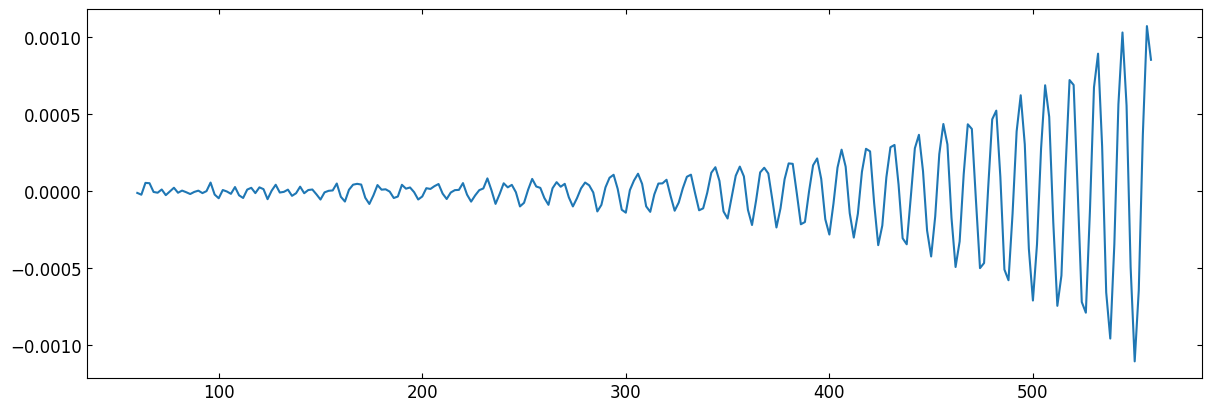

In [37]:
duration = 520
ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
data = "/2024-01-17/2024-01-17T143735_84bc5e10-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][30:30+250]
print(x)
y = dd['waveform']['values'][id][30:30+250]

## photon shape ### 
id = 4
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.00215715*np.exp(-0.00972759*exp_env_x)
exp_y = (exp_env_y* np.cos(2*np.pi* ph_if[id]*(exp_env_x*1e-9)))
time_reversed_waveform = np.array(exp_y[500:999])[::-1]

fig, ax = plt.subplots(figsize=(12,4),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

ax.plot(x, y[::-1])
# ax.plot(x, time_reversed_waveform*0.099)
ax.plot(exp_env_x, time_reversed_waveform)
plt.title("")
plt.legend("")
# ax.set_ylim(-0.18, 0.18)
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')
# plt.savefig('tr_waveform.png', bbox_inches='tight')
plt.show()

###ph num
y_env = time_reversed_waveform*0.129
pulse = [x, y, y_env]
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-ph_if[id]
print(rf_freq)
atten_fixed =  -50.36
atten_fridge = -20
atten_RT = -30
sample_rate = 2e-9
P_vna = 1.567e-5
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)


In [ ]:
amp_ph = [0.1175, 0.13, 0.142, 0.155, 0.167, 0.179, 0.1915,0.2035,  0.215, 0.227, 0.239, 0.251, 0.263, 0.275, 0.286, 0.298, 0.310, 0.322, 0.334, 0.346, 0.358]

10301110000.0
-118.40931003531409


0.03003973461712015

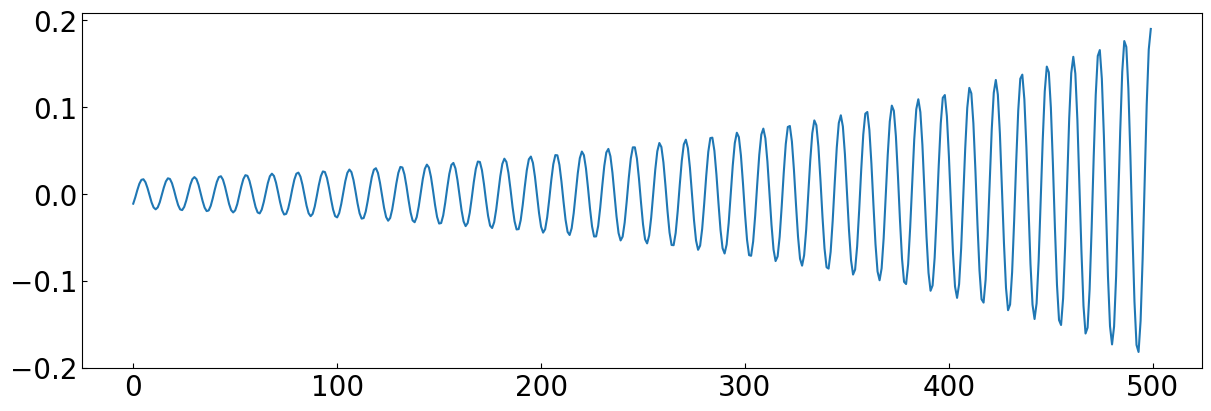

In [ ]:
id = 4
duration = 520
header = "D:/K_sunada/result/CDY154/"
data = "/2024-01-17/2024-01-17T143735_84bc5e10-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
y_shift =  y[13:duration-7]* np.exp(-1j*2 *np.pi* ph_if[id]*(x[13:duration-7]*1e-9))
y_LPF = np.array(np.abs(LPF(y_shift, 500e6, 15e6, 40e6, 5, 40))*2)

x = x[0+13:250+13]
y = y[0+13:250+13]*1e2
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
x = np.linspace(0, 499, 500)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
time_reversed_waveform = (y_env*np.cos(2*np.pi* ph_if[4]*(x*1e-9)))[::-1]
fig, ax = plt.subplots(figsize=(12,4),constrained_layout=True)
plt.plot(x, time_reversed_waveform)


y_env = time_reversed_waveform*0.282
pulse = [x, y, y_env]
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-ph_if[id]
print(rf_freq)
atten_fixed =  -50.36
atten_fridge = -20
atten_RT = -30
sample_rate = 2e-9
P_vna = 1.567e-5
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)

In [ ]:
half_decay_amp_tm = [0.089, 0.163, 0.230, 0.282, 0.326]
half_decay_amp = [0.282, 0.515, 0.728, 0.891, 1.029]
half_decay_amp_1 = [1.151, 1.261, 1.362]

In [ ]:
def photon_number_mode(mode_id):
    id = 4
    amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
    # gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
    gamma = np.linspace(0.005, 0.007, 21)
    x = np.linspace(0, 499, 500)
    y_env = amp[id]*np.exp(-gamma[mode_id]*(x+26))[::-1]*1e2
    
    ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
    time_reversed_waveform = (y_env*np.cos(2*np.pi* ph_if[4]*(x*1e-9)))
    plt.plot(x, time_reversed_waveform*0.099)
    plt.plot(x, y_env*0.099)
    pulse = [x, time_reversed_waveform, y_env*0.099]
    readout_lo_freq = 10.38e9
    rf_freq = readout_lo_freq-ph_if[id]
    atten_fixed =  -50.36
    atten_fridge = -20
    atten_RT = -30 + 10
    sample_rate = 2e-9
    P_vna = 1.567e-5
    ph_num = photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)
    return ph_num, 0.03/ph_num

-108.40931003531409


(0.05724549932033926, 0.5240586658546453)

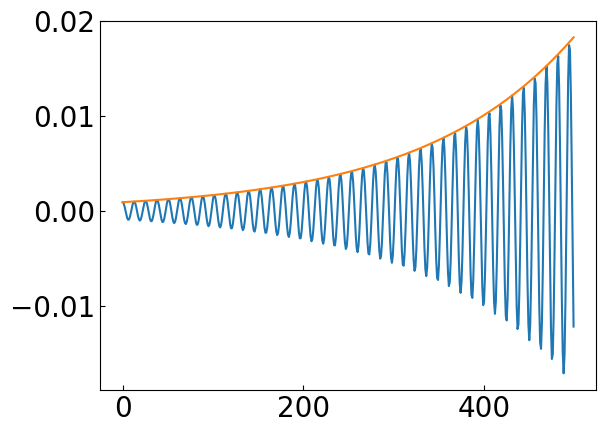

In [ ]:
photon_number_mode(10)

10301110000.0
-118.40931003531409


0.777295014207326

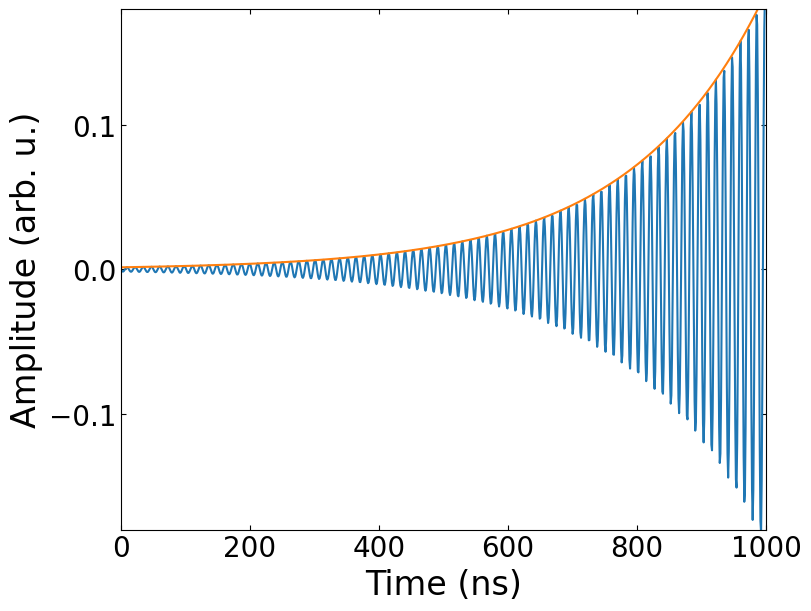

In [ ]:
photon_amplitude =[0.338, 0.617, 0.872, 1.068, 1.233] #square
photon_amplitude = [0.282, 0.515, 0.728, 0.891, 1.029] #tr

ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
data_id = 4
# time_reversed_waveform = np.array(square(ph_if[4], 0.05, 500) )

# time_reversed_waveform = square(ph_if[data_id], 0.05, 500)
## photon shape ### 
id = 4
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.title("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')

amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
ph_duration = 999
x = np.linspace(0, ph_duration-1, ph_duration)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
time_reversed_waveform = (y_env*np.cos(2*np.pi* ph_if[4]*(x*1e-9)))[::-1]
y_env = y_env[::-1]
plt.plot(x, time_reversed_waveform)
plt.plot(x, y_env)
plt.xlim(0, 1000)
plt.ylim(-0.18, 0.18)
ax.set_yticks([-0.1, 0, 0.1])
# plt.savefig('waveform1000_defence.png', bbox_inches='tight')

##ph num

pulse = [x, y, y_env]
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-ph_if[id]
print(rf_freq)
atten_fixed =  -50.36
atten_fridge = -20
atten_RT = -30 
sample_rate = 2e-9
P_vna = 1.567e-5
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)


In [ ]:
1/0.00972759*10

1028.003852958441

In [ ]:
ph_duramp = [0.197, 0.196, 0.1955, 0.195, 0.1945]

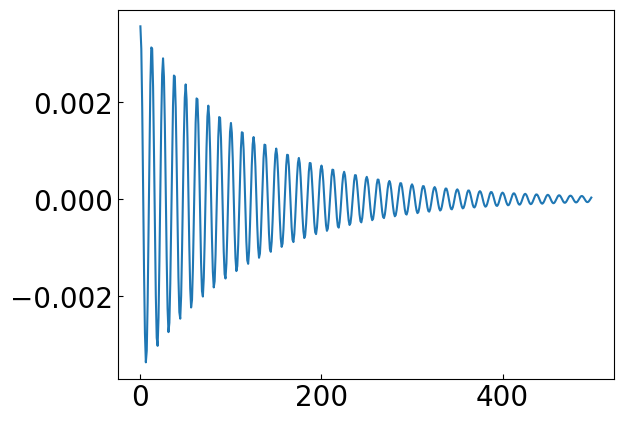

In [ ]:

fogi_delay = 29
fogi_amp = 0.6
fogi_duration = 500
fogi_freq = 5.3905

ph_phase = [0, np.pi/2, np.pi, -np.pi/2]

ph_if = [76e6, 79e6, 80e6, 76e6, 85e6, 92.5e6, 87.5e6, 80e6, 95e6, 80e6]
data_id = 2
ph_amp =0.338#(10dB)[0.222, 0.405,0.573, 0.702, 0.811] #[0.7, 1.28, 1.81, 2.22, 2.56]
# ph_amp = 3.03 #(10dB)[3.03, 5.53, 7.83, 9.6, 11.07]#[9.6, 17.5, 24.8, 30.3, 35]


exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.6335*np.exp(-0.00819161*exp_env_x)
exp_y = (exp_env_y* np.cos(2*np.pi* ph_if[2]*(exp_env_x*1e-9)))
time_reversed_waveform = np.array( exp_y[500:999])#[::-1] 
control_pulse = time_reversed_waveform  * ph_amp 
    
plt.plot(np.linspace(0, 498, 499), control_pulse)

In [ ]:
ph_amp_tr = [0.098, 0.180, 0.254, 0.311, 0.359]

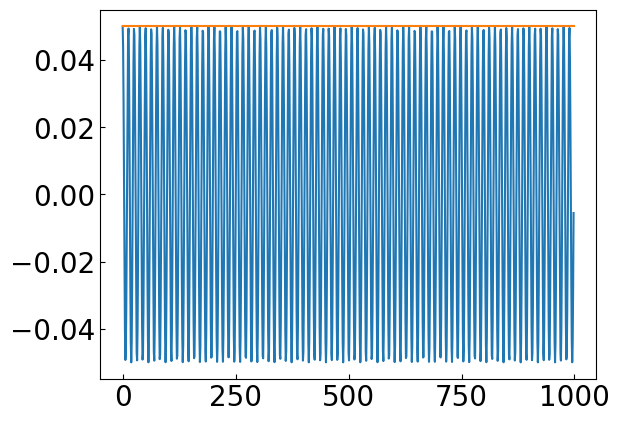

10301110000.0
-118.40931003531409


0.027890427058468704

In [ ]:

ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
ph_amp =0.23#[0.222, 0.405,0.573, 0.702, 0.811] #[0.7, 1.28, 1.81, 2.22, 2.56](1 + 0.5 * ph_amp_id)
pulse =np.array(square(ph_if[4], 0.05, 999) ) 

plt.plot(pulse[0], pulse[1])
plt.plot(pulse[0], pulse[2])
# plt.savefig('sq_waveform.png', bbox_inches='tight')
plt.show()
###ph num
pulse = [pulse[0], pulse[1],pulse[2]* ph_amp]
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-ph_if[id]
print(rf_freq)
atten_fixed =  -50.36
atten_fridge = -20
atten_RT = -30
sample_rate = 2e-9
P_vna = 1.567e-5
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)


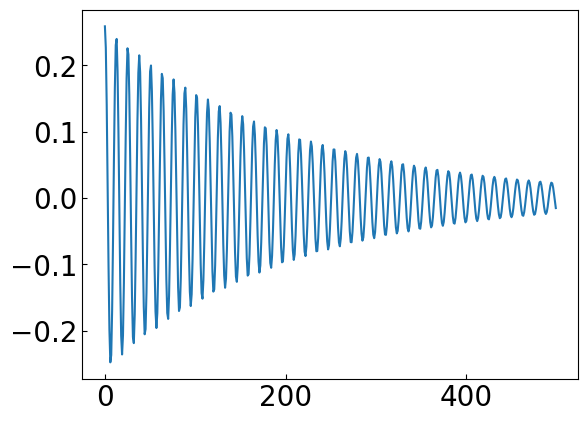

In [ ]:
id = 4
duration = 520
header = "D:/K_sunada/result/CDY154/"
data = "/2024-01-17/2024-01-17T143735_84bc5e10-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
y_shift =  y[13:duration-7]* np.exp(-1j*2 *np.pi* ph_if[id]*(x[13:duration-7]*1e-9))
y_LPF = np.array(np.abs(LPF(y_shift, 500e6, 15e6, 40e6, 5, 40))*2)

x = x[0+13:250+13]
y = y[0+13:250+13]*1e2
amp = [5.0130e-04, 8.1523e-04, 0.00122458, 0.00150458, 0.00215715, 0.00246627, 0.00290790, 0.00604601]
gamma = [0.00147027, 0.00264687, 0.00458680, 0.00656348, 0.00972759	, 0.01271420, 0.01645340, 0.02609383]
x = np.linspace(0, 499, 500)
y_env = amp[id]*np.exp(-(gamma[id]/2)*(x+26))*1e2
time_reversed_waveform = (y_env*np.cos(2*np.pi* ph_if[4]*(x*1e-9)))#[::-1]

plt.plot(x, time_reversed_waveform*1.362)

In [ ]:
sq_ph_du = [0.377, 0.338, 0.308, 0.285, 0.266, 0.251, 0.239]

In [ ]:
ph_amp_sq_10 = [0.107, 0.195, 0.276, 0.338, 0.390]

In [ ]:
ph_amp_sq = [0.338, 0.617, 0.872, 1.068, 1.233]
ph_amp_sq1 = [1.379, 1.511, 1.631]

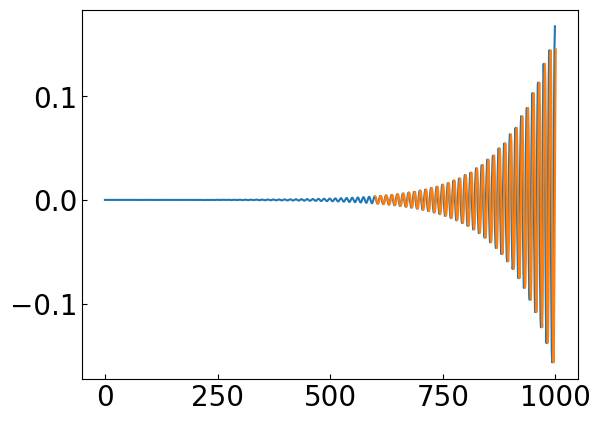

In [ ]:
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y = 0.00215715*np.exp(-0.00972759*(exp_env_x+26))*1e2
exp_y = (exp_env_y* np.cos(2*np.pi* 80e6*(exp_env_x*1e-9)))[::-1]
length = 400
plt.plot(exp_env_x, exp_y)
control_pulse = np.array(exp_y[999-length:999])# *0.311
plt.plot(np.linspace(0, len(control_pulse)+1, len(control_pulse))+600, control_pulse)



In [ ]:
photon_amplitude = [0.311, 0.568, 0.803, 0.983, 1.135]

In [ ]:
def time_reverse(data, id,f_if, duration, awg):
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][id][0:duration]
    y = dd['waveform']['values'][id][0:duration]
    y = y[::-1]
    y1 =  y* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
    y_LPF = np.array(np.abs(LPF(y1, 500e6, 10e6, 30e6, 5, 40))*2**0.5)*awg
    
    x_comp = []
    y_comp = []
    for i in range(len(y_LPF)-1):
        x_comp.append(x[i])
        x_comp.append((x[i]+x[i+1])/2)
        y_comp.append(y_LPF[i])
        y_comp.append((y_LPF[i]+y_LPF[i+1])/2)
    x_comp.append(x[-1])
    x_comp.append(x[-1]+1)
    y_comp.append(y_LPF[-1])
    y_comp.append(y_LPF[-1])
    time = np.array(x_comp)
    control_pulse = np.array(y_comp) * np.cos(2*np.pi* f_if*(time*1e-9))
    return x_comp, control_pulse, np.array(y_comp)

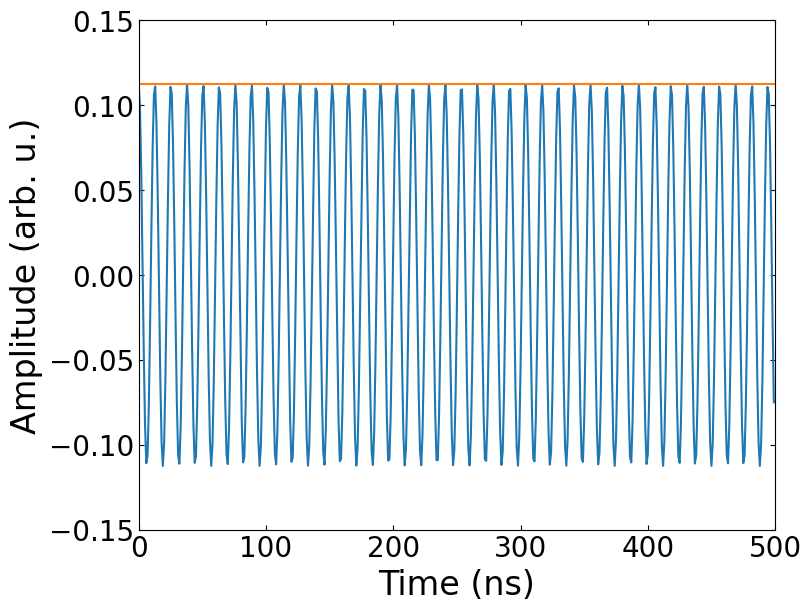

In [ ]:
## square 0.03-1.21
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.title("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')

ph_if = [74.04e6, 77.88e6, 78.85e6, 78.85e6, 78.89e6, 80.00e6, 75.71e6, 80.00e6, 85.00e6]
ph_amp =0.15#[0.222, 0.405,0.573, 0.702, 0.811] #[0.7, 1.28, 1.81, 2.22, 2.56](1 + 0.5 * ph_amp_id)
pulse = np.array(square(ph_if[4], 0.05, 500) )* ph_amp
plt.ylim(-0.15, 0.15)

plt.plot(pulse[0]/ph_amp, pulse[1]*15)
plt.plot(pulse[0]/ph_amp, pulse[2]*15)
plt.xlim(0, 500)
# plt.savefig('sq_waveform.png', bbox_inches='tight')
plt.show()

In [ ]:
3/0.00819161

366.2283726886412